# `11_cecg_sqi_composite.ipynb` — four cECG quality indices + a tunable composite

Built from the convergence of your eye-test, the correctness-AUC ranking, and Warnecke et al. (2026)'s
capacitive-ECG artifact index. We keep only the four indices that actually measure cECG quality and drop the
spike-rewarding ones (kSQI, sSQI):

- **bSQI** — R-peak-detector agreement (Warnecke's single best cECG index).
- **corSQI** — Orphanidou template correlation: each QRS vs the window's average QRS (a *properly done* tSQI).
- **pSQI** — relative power in the QRS band (your eye-test front-runner: rewards periodic energy, not spikes).
- **aSQI** — amplitude uniformity across sub-segments (Warnecke's proposal; drops sharply on localized
  motion bursts, highest specificity in their study).

For each you get the **bad (5th pct) vs good (95th pct) raw-cECG eye-test**, then a **composite** you can
re-weight freely. Every index is **robustly normalized to [0,1]** before combining (percentile 2–98 min-max,
clipped), so no single index's scale can dominate the composite — with weights summing to 1, the composite
stays in [0,1] by construction. Self-contained; corSQI/aSQI are computed from the raw cECG (real data), with
a synthetic fallback so it all runs.

## 1 · Setup + cECG expert correctness + raw-cECG cache + the four SQIs

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks

os.chdir('/home/nik/projects/BA')

REPO_SRC, DATA_ROOT = "src/", "data/patients"
AF_LIST, RESULTS_DIR = "data/AF_patients.txt", "results/11"
FS, WINDOW_SEC, HOP_SEC, BCG_MODE, RANDOM_STATE = 128, 30, 15, "wavelet", 0
EXCLUDE_PATIENTS = []
WIN, HOP = WINDOW_SEC*FS, HOP_SEC*FS
os.makedirs(RESULTS_DIR, exist_ok=True); sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score

try:
    import extract as X
    from signal_loader import PatientSignals
    HAVE_REPO = True
except Exception as e:
    HAVE_REPO = False; print("repo src not importable ->", e)

def synthetic(n_pat=40, win=40, seed=RANDOM_STATE):
    rng=np.random.default_rng(seed); rows,ys=[],[]
    for pid in range(n_pat):
        for w in range(win): rows.append(f"PAT{pid:03d}"); ys.append(pid%2)
    N=len(ys); yv=np.array(ys)
    base=rng.uniform(0,1,N); qual=np.clip(0.7*base+0.3*rng.uniform(0,1,N),0,1)
    data={"patient":rows,"win_idx":np.tile(np.arange(win),n_pat),
          "t_start_s":np.tile(np.arange(win)*HOP_SEC,n_pat),"AF":yv.astype(float),"y":yv.astype(float)}
    data["sqi_cecg_bSQI"]=np.clip(qual+0.2*rng.standard_normal(N),0,1)
    data["sqi_cecg_pSQI"]=np.clip(qual+0.3*rng.standard_normal(N),0,1)
    lab=pd.DataFrame(data); lab.attrs["_qual"]=qual
    return lab

if HAVE_REPO and os.path.exists(DATA_ROOT):
    cfg=X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS, window_s=WINDOW_SEC,
                        hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    lab=X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS: lab=lab[~lab["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    lab["y"]=lab["AF"].astype(float); lab=lab.dropna(subset=["y"]).reset_index(drop=True)
    CECG_FEAT=X.expert_feature_cols(lab,"cecg"); SYNTHETIC=False; print("REAL data:", lab.shape)
else:
    print("!!! SYNTHETIC FALLBACK !!!"); lab=synthetic(); CECG_FEAT=[]; SYNTHETIC=True

y=lab["y"].astype(int).values; groups=lab["patient"].values

# cECG expert OOF correctness (target for the AUC annotations)
if not SYNTHETIC:
    Xm=lab[CECG_FEAT].to_numpy(float); p_cecg=np.full(len(lab),np.nan)
    for tr,te in LeaveOneGroupOut().split(Xm,y,groups):
        if len(np.unique(y[tr]))<2: p_cecg[te]=y[tr].mean(); continue
        clf=HistGradientBoostingClassifier(random_state=RANDOM_STATE)
        clf.fit(Xm[tr],y[tr],sample_weight=compute_sample_weight("balanced",y[tr]))
        p_cecg[te]=clf.predict_proba(Xm[te])[:,1]
else:
    rng=np.random.default_rng(1); q=lab.attrs["_qual"]
    p_cecg=np.clip(q*np.where(y==1,.85,.15)+(1-q)*rng.uniform(0,1,len(y)),1e-3,1-1e-3)
correct=((p_cecg>=0.5).astype(int)==y).astype(int)

# ---- cache ALL raw cECG windows (so re-weighting re-plots instantly) ----
def cecg_windows():
    if not SYNTHETIC:
        for pid, sub in lab.groupby("patient"):
            try:
                pat=PatientSignals(os.path.join(DATA_ROOT,pid)); pat.filter_all(fs=FS); pat.offset_correction(fs=FS)
                cec=pat.cecg_filt
                for idx,r in sub.iterrows():
                    s=int(round(r.t_start_s*FS)); yield idx, np.asarray(cec[s:s+WIN],np.float32)
            except Exception as e:
                print(f"  {pid}: {e}")
                for idx in sub.index: yield idx, np.full(WIN,np.nan,np.float32)
    else:
        rng=np.random.default_rng(7); q=lab.attrs["_qual"]
        for idx in lab.index:
            ww=np.zeros(WIN,np.float32); hr=rng.uniform(0.9,1.4)
            for L in np.arange(0.3,WINDOW_SEC,1/hr):
                i=int(L*FS)
                if 4<=i<WIN-4: ww[i-3:i+3]+=q[idx]*np.array([.2,.6,1.,1.,.6,.2],np.float32)
            ww+=((1-q[idx])*rng.standard_normal(WIN)*0.5).astype(np.float32)
            if idx%37==0: ww[10*FS:12*FS]+=(rng.standard_normal(2*FS)*4).astype(np.float32)  # some bursts
            yield idx, ww
CECG_RAW={idx:w for idx,w in cecg_windows()}
print("cached", len(CECG_RAW), "raw cECG windows")


Kein Cache -> extrahiere ...
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped gt_ecg


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_offset = 182  final_offset = 81
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
  flipped gt_ecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 195  final_offset = 90
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 446  final_offset = 337
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 254  final_offset = 160
  trim_start_s   = 0.00  trim_end_s = 0.00


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 329  final_offset = 224
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 311  final_offset = 205
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 250  final_offset = 138
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 216  fi

In [2]:
# ---- the four SQIs ----
def _peaks(w, fs):
    w=np.asarray(w,float)
    if w.size<8 or not np.isfinite(w).all() or np.std(w)<1e-9: return np.array([],int), w
    s=w-np.median(w); s=s if abs(s.max())>=abs(s.min()) else -s
    pk,_=find_peaks(s, distance=int(0.3*fs), prominence=np.std(s)*0.5)
    return pk, s

def corSQI(w, fs, half=0.06):
    """Orphanidou: mean correlation of each QRS to the window-average QRS template. [-1,1]."""
    pk,s=_peaks(w,fs); L=int(half*fs)
    beats=[s[p-L:p+L] for p in pk if p-L>=0 and p+L<len(s)]
    if len(beats)<3: return 0.0
    B=np.array(beats); tmpl=B.mean(0)
    cs=[np.corrcoef(b,tmpl)[0,1] for b in B if np.std(b)>1e-9]
    cs=[c for c in cs if np.isfinite(c)]
    return float(np.mean(cs)) if cs else 0.0

def aSQI(w, fs, part_s=2.0):
    """Amplitude uniformity: min/max of per-2s-part max-abs amplitude. [0,1]; low=motion burst."""
    w=np.asarray(w,float)
    if not np.isfinite(w).all() or np.std(w)<1e-9: return 0.0
    pl=int(part_s*fs); n=len(w)//pl
    if n<2: return 0.0
    M=[np.max(np.abs(w[j*pl:(j+1)*pl])) for j in range(n)]
    mx=max(M); return float(min(M)/mx) if mx>0 else 0.0

# raw-derived
corsqi=np.array([corSQI(CECG_RAW[i],FS) for i in lab.index])
asqi  =np.array([aSQI(CECG_RAW[i],FS)  for i in lab.index])
# table-derived (already [0,1]); fall back gracefully if absent
bsqi=np.nan_to_num(lab.get("sqi_cecg_bSQI", pd.Series(np.full(len(lab),0.5))).to_numpy(float))
psqi=np.nan_to_num(lab.get("sqi_cecg_pSQI", pd.Series(np.full(len(lab),0.5))).to_numpy(float))

RAW_SQI = {"bSQI": bsqi, "corSQI": corsqi, "pSQI": psqi, "aSQI": asqi}

# ---- robust normalize each to [0,1] (percentile 2-98 min-max, clipped) ----
def robust_unit(v):
    v=np.asarray(v,float); fin=np.isfinite(v)
    if fin.sum()==0: return np.full_like(v,0.5)
    lo,hi=np.percentile(v[fin],2), np.percentile(v[fin],98)
    if hi-lo<1e-9: return np.clip((v-lo),0,1) if np.std(v[fin])>0 else np.full_like(v,0.5)
    out=np.clip((v-lo)/(hi-lo),0,1); out[~fin]=0.5; return out
NORM_SQI = {k: robust_unit(v) for k,v in RAW_SQI.items()}
print("normalized to [0,1]:", {k: (round(float(NORM_SQI[k].min()),2), round(float(NORM_SQI[k].max()),2)) for k in NORM_SQI})


normalized to [0,1]: {'bSQI': (0.0, 1.0), 'corSQI': (0.0, 1.0), 'pSQI': (0.0, 1.0), 'aSQI': (0.0, 1.0)}


## 2 · Eye-test, one graph per index — bad (5th pct) vs good (95th pct) raw cECG

Each figure: the window the index scores low (left, red) and high (right, green). The header shows that
index's overall **correctness-AUC** (how well it predicts the cECG expert being right). Judge by eye whether
"good" really looks like a clean QRS train and "bad" like noise/flatline/burst.

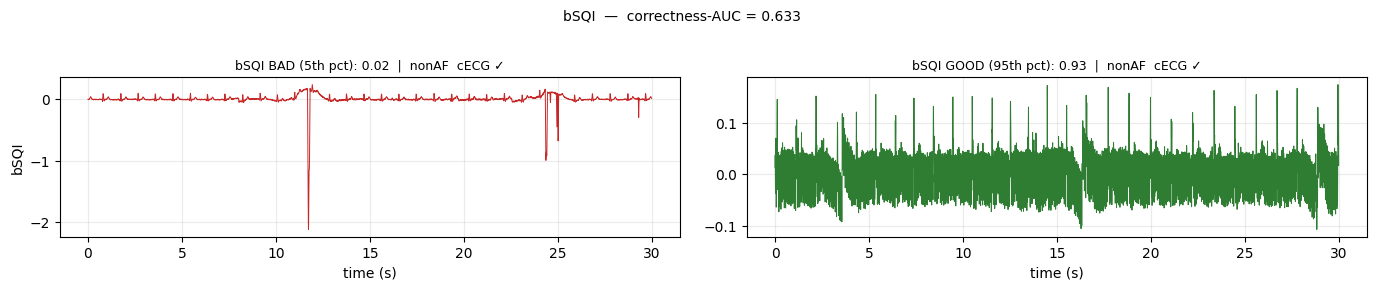

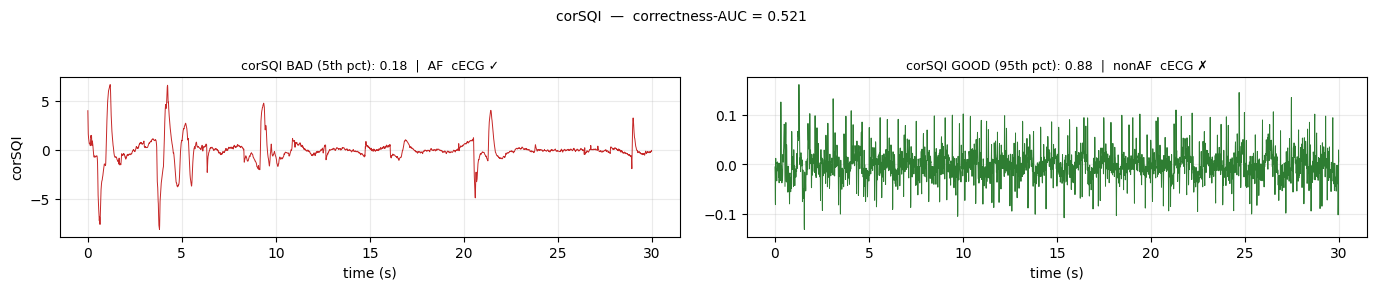

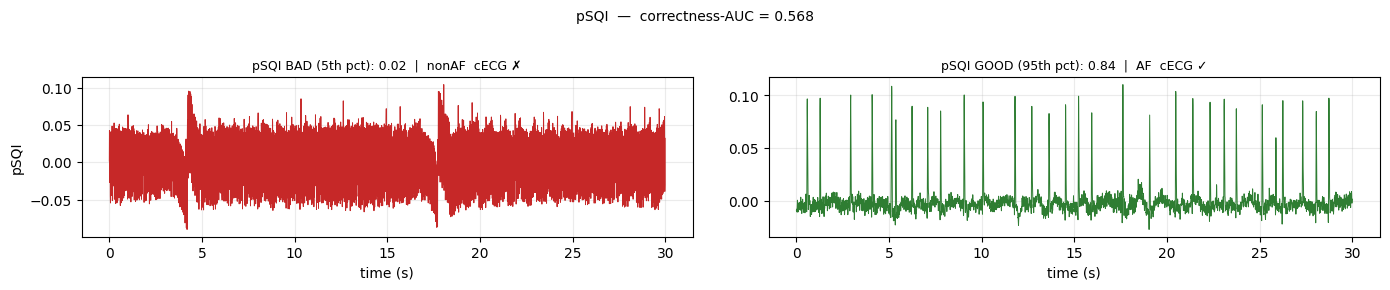

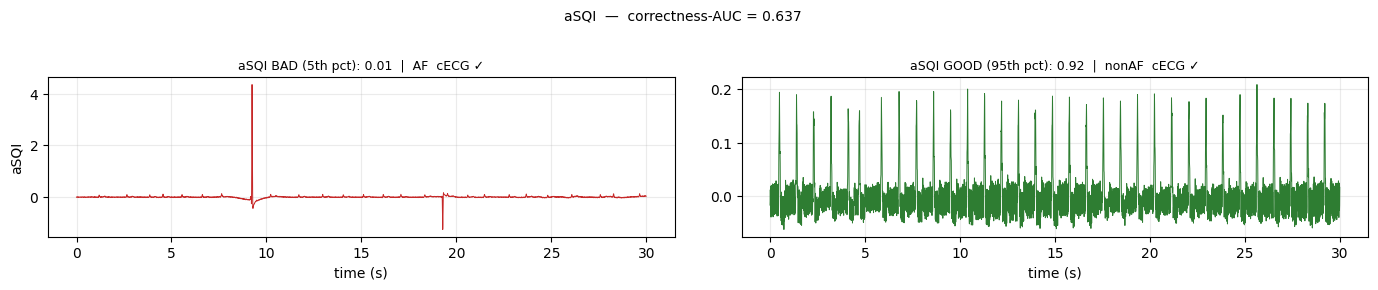

In [3]:
def pick(vals, pct):
    v=np.asarray(vals,float); fin=np.isfinite(v)
    if fin.sum()==0: return None
    t=np.percentile(v[fin],pct); cand=np.where(fin)[0]
    return int(cand[np.argmin(np.abs(v[cand]-t))])

def auc_correct(s):
    s=np.nan_to_num(s)
    return roc_auc_score(correct,s) if len(np.unique(correct))==2 and np.std(s)>1e-9 else np.nan

def eyetest(name, vals):
    lo, hi = pick(vals,5), pick(vals,95); t=np.arange(WIN)/FS
    fig,ax=plt.subplots(1,2,figsize=(14,2.8),sharex=True)
    for a,(idx,tag,col) in zip(ax,[(lo,"BAD (5th pct)","#c62828"),(hi,"GOOD (95th pct)","#2e7d32")]):
        if idx is None or idx not in CECG_RAW: a.text(.5,.5,"n/a",ha="center"); continue
        a.plot(t, CECG_RAW[idx], lw=.7, color=col)
        ok="✓" if correct[idx]==1 else "✗"; tru="AF" if y[idx]==1 else "nonAF"
        a.set_title(f"{name} {tag}: {vals[idx]:.2f}  |  {tru}  cECG {ok}", fontsize=9); a.grid(alpha=.25)
    ax[0].set_ylabel(name); ax[1].set_xlabel("time (s)"); ax[0].set_xlabel("time (s)")
    fig.suptitle(f"{name}  —  correctness-AUC = {auc_correct(NORM_SQI[name]):.3f}", fontsize=10, y=1.02)
    plt.tight_layout(); plt.show()

for name in ["bSQI","corSQI","pSQI","aSQI"]:
    eyetest(name, NORM_SQI[name])


## 3 · The composite — tune the weights and watch it change

`WEIGHTS` starts at **equal weighting**. The composite is `Σ wᵢ·norm_SQIᵢ / Σ wᵢ`, so it stays in [0,1].
Edit the numbers, re-run this cell, and the eye-test + correctness-AUC update. (If you `pip install
ipywidgets`, the slider block at the bottom gives live control.)

weights (raw): bSQI=1.00  corSQI=1.00  pSQI=1.00  aSQI=1.00
composite correctness-AUC = 0.629   (components: bSQI=0.633  corSQI=0.521  pSQI=0.568  aSQI=0.637)


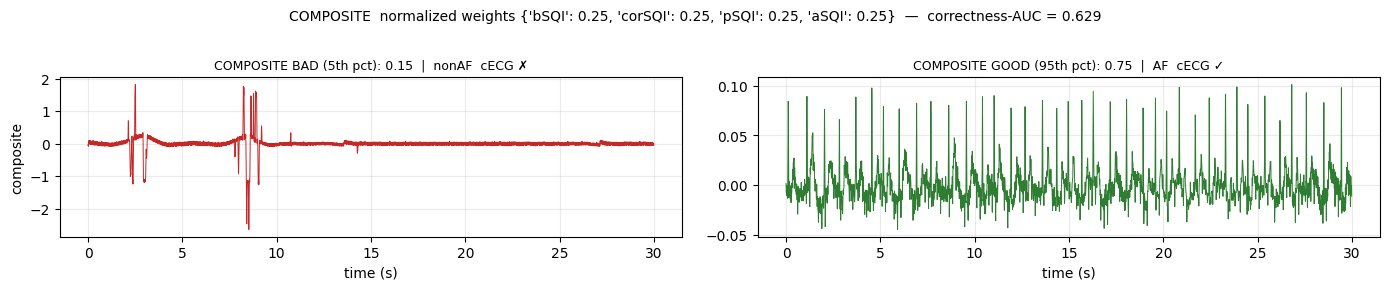

In [4]:
WEIGHTS = {"bSQI": 1.0, "corSQI": 1.0, "pSQI": 1.0, "aSQI": 1.0}   # <-- EDIT ME, then re-run

def composite(weights):
    w = np.array([max(weights.get(k,0.0),0.0) for k in NORM_SQI]); 
    w = w/ w.sum() if w.sum()>0 else np.ones(len(NORM_SQI))/len(NORM_SQI)
    M = np.column_stack([NORM_SQI[k] for k in NORM_SQI])
    return M @ w                                  # in [0,1]

def render(weights):
    c = composite(weights)
    parts = "  ".join(f"{k}={v:.2f}" for k,v in weights.items())
    print(f"weights (raw): {parts}")
    print(f"composite correctness-AUC = {auc_correct(c):.3f}   "
          f"(components: " + "  ".join(f"{k}={auc_correct(NORM_SQI[k]):.3f}" for k in NORM_SQI) + ")")
    eyetest_composite(c, weights)

def eyetest_composite(c, weights):
    lo, hi = pick(c,5), pick(c,95); t=np.arange(WIN)/FS
    fig,ax=plt.subplots(1,2,figsize=(14,2.8),sharex=True)
    for a,(idx,tag,col) in zip(ax,[(lo,"BAD (5th pct)","#c62828"),(hi,"GOOD (95th pct)","#2e7d32")]):
        if idx is None: a.text(.5,.5,"n/a",ha="center"); continue
        a.plot(t, CECG_RAW[idx], lw=.7, color=col)
        ok="✓" if correct[idx]==1 else "✗"; tru="AF" if y[idx]==1 else "nonAF"
        a.set_title(f"COMPOSITE {tag}: {c[idx]:.2f}  |  {tru}  cECG {ok}", fontsize=9); a.grid(alpha=.25)
    ax[0].set_ylabel("composite"); ax[0].set_xlabel("time (s)"); ax[1].set_xlabel("time (s)")
    wn = {k: round(v/sum(max(x,0) for x in weights.values()),2) for k,v in weights.items()}
    fig.suptitle(f"COMPOSITE  normalized weights {wn}  —  correctness-AUC = {auc_correct(c):.3f}",
                 fontsize=10, y=1.02)
    plt.tight_layout(); plt.show()

render(WEIGHTS)


### Optional: live sliders (`pip install ipywidgets`)

In [ ]:
try:
    import ipywidgets as W
    from IPython.display import display
    sliders = {k: W.FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description=k) for k in NORM_SQI}
    def _go(**kw): render(kw)
    display(W.interactive(_go, **sliders))
except Exception as e:
    print("ipywidgets not available -> edit the WEIGHTS dict above and re-run. (", e, ")")


interactive(children=(FloatSlider(value=1.0, description='bSQI', max=3.0), FloatSlider(value=1.0, description=…

## 4 · Reading it

- The per-index **correctness-AUC** in each header tells you how much each index is worth; the eye-test tells
  you *why*. Expect pSQI/bSQI/corSQI to show clean-QRS "good" panels; aSQI's value is catching **localized
  motion bursts** (its "bad" window should have one loud stretch and quiet rest).
- In the composite, push the weight toward whichever index has the highest correctness-AUC and watch the
  composite's AUC rise — but keep aSQI in the mix even if its AUC is modest, because its **specificity** (not
  discarding good windows) is its contribution, per Warnecke et al.
- Because everything is normalized to [0,1] first, the weights are directly comparable — a weight of 2 on
  pSQI genuinely means "twice the say of a weight-1 index," not "whatever pSQI's raw scale happened to be."
- Once you settle on weights, that becomes your replacement cECG quality index: drop it into `sqi.py` as the
  cECG `composite`, or add it as a new `sqi_cecg_*` column so the fusion weight model picks it up — then
  re-run the fusion/abstention notebooks with the better index driving the weights. Repeat per signal (PPG/
  BCG will favor periodicity/inter-channel agreement over R-peak-based indices).